In [9]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

Google api key is set


In [10]:
from langchain_core.tools import tool
from typing import Optional, Literal
from flight_search import FlightSearch

fs = FlightSearch()
@tool
def flight_search_tool(
    source: Optional[str] = None,
    destination: Optional[str] = None,
    departure_date: Optional[str] = None,
    return_date: Optional[str] = None,
    passengers: Optional[int] = 1,
    travel_class: Optional[
        Literal["economy", "business", "first class"]
    ] = "economy",
    search_type: Literal[
        "direct",
        "calendar",
        "monthly",
        "popular"
    ] = "direct",
    ):
    """
    Tool that is used to search all available flight for departure or return using source and destionation according to travel class
    Args:
        source: From where user wants to book flight
        destination: to where user wants to go
        departure_date: date when user wants to go
        return_date: date when user wants to return
        passengers: no of travellers going
        travel_class: Which class user wants to go (economy/ business)
        search_type:
        - direct   -> Cheapest fare for the given route/date.
        - calendar -> Cheapest fare for every day of the month.
        - monthly  -> Cheapest fare for every month.
        - popular  -> Popular destinations from the source city.
    """
    origin = fs.city_lookup(source)

    if origin is None:
        return f"Could not find city {source}"

    
    if search_type == "popular":
        try:
            result = fs.popular_destination(
                origin= origin["code"]
            )

            return {
                "origin": source,
                "popular destinations": result
            }
        except Exception as e:
            return f"Failed: {e}"
        
    dest = fs.city_lookup(destination)
    
    if dest is None:
        return f"Could not find destination {destination}"

    try:
        if search_type == "direct":
            result = fs.search_direct_flights(
                        origin=origin["code"],
                        destination=dest["code"],
                        depart_date=departure_date,
                        return_date = return_date
                    )

        elif search_type == "calendar":
            result = fs.search_calender_prices(
                origin=origin["code"],
                destination=dest["code"],
                depart_date=departure_date,
                return_date=return_date,
            )

        elif search_type == "monthly":

            result = fs.search_monthly_prices(
                origin=origin["code"],
                destination=dest["code"],
            )

        else:
            return "Invalid search_type."

        return {
            "search_type": search_type,
            "source": origin["name"],
            "destination": dest["name"],
            "passengers": passengers,
            "travel_class": travel_class,
            "result": result,
        }

    except Exception as e:
        return f"Flight search failed: {str(e)}"

@tool
def train_search_tool(source: str, destination: str, journey_date: str, passengers: int, coach_class: Literal[
    "1A (First AC)",
    "2A (AC 2 Tier)",
    "3A (AC 3 Tier)",
    "3E (AC 3 Economy)",
    "CC (AC Chair Car)",
    "EC (Executive Chair Car)",
    "SL (Sleeper)",
    "2S (Second Sitting)"
    ]):
    """
    Tool that is used to search all available train tickets for journey based on departure date using source and destionation according to coach class provided
    Args:
        source: From where user wants to book flight
        destination: to where user wants to go
        departure_date: date when user wants to go
        passengers: no of travellers going
        coach_class: Which coach user wants to go in (1A (First AC), 
                    2A (AC 2 Tier),
                    3A (AC 3 Tier),
                    3E (AC 3 Economy)",
                    CC (AC Chair Car)",
                    EC (Executive Chair Car)",
                    SL (Sleeper)",
                    2S (Second Sitting))
    """

@tool
def bus_search_tool(source: str, destination: str, journey_date: str, passengers: int, bus_type: Literal["Non-AC Seater",
"AC Seater",
"Non-AC Sleeper",
"AC Sleeper",
"AC Semi-Sleeper",
"Volvo AC"
]):
    """
    Tool that is used to search all available bus tickets for journey based on departure date using source and destionation according to bus type provided
    Args:
        source: From where user wants to book flight
        destination: to where user wants to go
        departure_date: date when user wants to go
        passengers: no of travellers going
        bus_type: Which type of bus user prefers 
        -"Non-AC Seater",
        -"AC Seater",
        -"Non-AC Sleeper",
        -"AC Sleeper",
        -"AC Semi-Sleeper",
        -"Volvo AC"
    """

@tool
def hotel_search_tool(destination: str, check_in: str, check_out: str, guests: int, rooms: int, hotel_type: Literal[
    "Budget Friendly",
    "3 star",
    "4 star",
    "5 star",
    "Resort",
    "Hotel",
    "Villa",
    "Apartment"
], max_budget: float):
    """
    Tool search details for a hotel for user to check availability
    Args:
        destination: The city or location where the user wants to stay.
        check_in: The date the user will arrive and check into the hotel.
        check_out: The date the user will leave the hotel.
        guests: Total number of people staying in the hotel.
        rooms: Number of hotel rooms required. This depends on the number of guests and user preference.
        hotel_type: The preferred category or style of accommodation.
        max_budget: The maximum amount the user is willing to spend on accommodation. 
                    This can be per night or for the entire stay (be consistent in your tool design).
    """

@tool
def weather_tool(destination: str, start_date: str, end_date: str):
    """
    Tool to check the weather of destination user want to go from start date to end date
    Args:
        destination: The city or location user wants to go
        start_date: Date from when user tour starts
        end_date: date till user will be there
    """

@tool
def tourists_attraction_tool(destination: str, budget: Optional[float]):
    """
    Tool to search for tourist attraction places at the destination given
    Args:
        destination: The City or location user went to travel
        budget: amount of money to visit tourist place (optional)
    """

@tool
def restaurant_search_tool(destination: str, cuisine: Literal[
    "Indian",
"Chinese",
"Italian",
"Mexican",
"Thai",
"Japanese",
"Korean",
"Continental",
"Mediterranean",
"Fast Food",
"Cafe",
"Bakery",
"Seafood",
"Street Food"
"Any"
], meal_type: Literal[
    "Breakfast",
    "Brunch",
    "Lunch",
    "Evening Snacks",
    "Dinner",
    "Late Night",
    ]):
    """
    Tool used to search for restaurant based on user preferences
    Args:
        destination: The city or location user wants to go
        cuisine: Type of dish user prefer to eat
        meal_type: type of meal(breakfast, brunch, lunch etc)
    """

@tool
def budget_estimator_tool(destination: str, total_budget:str, trip_duration: str, travellers: str):
    """
    Tool used to estimate budget according to plans
    Args:
        destination: The city or location user is travelling
        total_budget: Total amount user plan to spent
        trip_duration: No of days user want to spent
        travellers: No of people going for tour
    """

In [11]:
tools = [flight_search_tool, train_search_tool, bus_search_tool, hotel_search_tool, restaurant_search_tool, budget_estimator_tool, tourists_attraction_tool, weather_tool]

llm_with_tool = llm.bind_tools(tools)

In [12]:
from typing import TypedDict, List, Annotated
from langgraph.graph.message import add_messages, BaseMessage

class graph_schema(TypedDict):
    messages: Annotated[List[BaseMessage], add_messages]
    missing_fields: list[str]

In [13]:
REQUIRED_FIELDS = {
    "flight_search_tool": {
    "direct": [
        "source",
        "destination",
        "departure_date"
    ],
    "calendar": [
        "source",
        "destination",
        "departure_date"
    ],
    "monthly": [
        "source",
        "destination"
    ],
    "popular": [
        "source"
    ]
},
    "hotel_search_tool": [
        "destination",
        "check_in",
        "check_out",
        "guests",
        "rooms",
        "hotel_type",
        "max_budget"
    ],
    "train_search_tool": [
        "source",
        "destination",
        "journey_date",
        "passengers",
        "coach_class"
    ],
    "bus_search_tool": [
        "source",
        "destination",
        "journey_date",
        "passengers",
        "bus_type"
    ],
    "weather_tool": [
        "destination",
        "start_date",
        "end_date"
    ],
    "restaurant_tool": [
        "destination",
        "cuisine",
        "meal_type"
    ],
    "tourists_attraction_tool": [
        "destination"
    ],
    "budget_estimator_tool": [
        "destination",
        "total_budget",
        "tip_duration",
        "travellers"
    ]
}

In [14]:
from langchain_core.messages import ToolMessage, HumanMessage

def llm_node(state: graph_schema) -> graph_schema:
    messages = state['messages']
    response = llm_with_tool.invoke(messages)
    return{
        "messages": [response]
    }

def tool_node(state: graph_schema) -> graph_schema:
    messages = state['messages']
    tool_by_name = {tool.name: tool for tool in tools}

    tool_result = []
    for tool_call in messages[-1].tool_calls:
        tool = tool_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_call["id"]))

    return {
        "messages": tool_result
    }

def tool_needed(state: graph_schema) -> graph_schema:
    messages = state['messages']
    if messages[-1].tool_calls:
        return "tool_node"
    else:
        return "end"

def validation_node(state: graph_schema) -> graph_schema:
    messages = state["messages"]

    all_missing = {}

    last_message = messages[-1]

    for tool_call in last_message.tool_calls:

        tool_name = tool_call["name"]
        args = tool_call["args"]

        if tool_name == "flight_search_tool":
            search_type = args.get("search_type", "direct")
            required = REQUIRED_FIELDS[tool_name][search_type]
        else:
            required = REQUIRED_FIELDS[tool_name]

        missing = [
            field
            for field in required
            if not args.get(field)
        ]

        if missing:
            all_missing[tool_name] = missing

    # Nothing missing -> continue to tool execution
    if not all_missing:
        return {
            "missing_fields": {}
        }

    # Build a natural prompt for the LLM
    prompt = ""

    for tool_name, fields in all_missing.items():
        prompt += f"""
The user wants to use the tool '{tool_name}'.

Missing fields:
{', '.join(fields)}

Ask naturally for ONLY these missing details.
Do not ask for anything already provided.

"""

    response = llm.invoke(prompt)

    return {
        "messages": [response],
        "missing_fields": all_missing
    }
def validation_route(state):
    if state.get("missing_fields"):
        return "ask_user"
    return "tool_node"

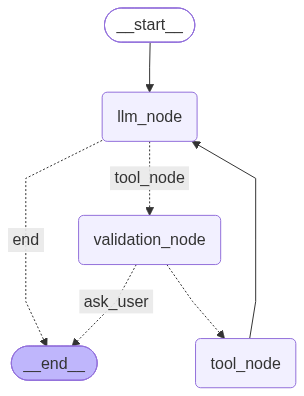

In [15]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("validation_node", validation_node)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "llm_node")

graph.add_conditional_edges(
    "llm_node",
    tool_needed,
    {
        "tool_node": "validation_node",
        "end": END
    }
)

graph.add_conditional_edges(
    "validation_node",
    validation_route,
    {
        "tool_node": "tool_node",
        "ask_user": END
    }
)

graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

travel_planner_graph = graph.compile()
travel_planner_graph

In [16]:
messages = []

while True:
    query = input("Enter task to proceed (stop to end task)")

    if query.lower() == "end":
        print("Bye bye")
        break

    messages.append(HumanMessage(content=query))
    result  = travel_planner_graph.invoke({
        "messages": messages
    })

    messages = result["messages"]

    print("Agent:", messages[-1].content)

Agent: [{'type': 'text', 'text': 'Based on current data, there are no direct or popular flight options from Kolkata (CCU) available for under ₹7,000. The available flights to major cities like Delhi, Mumbai, and Chennai currently start well above that price point.\n\nIf you are looking for travel options within that budget, you might consider:\n*   **Checking for Last-Minute Deals:** Prices can fluctuate significantly; it\'s often worth checking travel aggregator sites closer to your intended travel dates.\n*   **Exploring Other Modes of Transport:** For shorter distances, trains or buses are often significantly cheaper than flights and can easily fit within a ₹7,000 budget.\n*   **Flexible Dates:** If your travel dates are flexible, searching for "calendar" or "monthly" views on booking platforms can sometimes reveal cheaper days to fly.\n\nIf you would like me to check train or bus options for a specific destination, please let me know where you are planning to go and when!', 'extras

In [17]:
import json

result = fs.search_direct_flights(
    origin="IXR",
    destination="GOI",
    depart_date="2026-08-06",
    return_date="2026-08-10",
    currency="INR"
)

print(json.dumps(result, indent=2))

{
  "data": {},
  "currency": "INR",
  "success": true
}
